# Deep Learning: Assignment #2
## Submission date: 24/12/2025, 23:59.
### Topics:
- Regularization
- Batch Normalization
- Convolutional Neural Networks
- Semantic Segmentation


**Submitted by:**

- **Yosef Asadi**
- **Aisha Abu Dahesh**  


**Assignment Instructions:**

· Submissions are in **pairs only**. Write both names + IDs at the top of the notebook.

· Keep your code **clean, concise, and readable**.

· You may work in your IDE, but you **must** paste the final code back into the **matching notebook cells** and run it there.  


· <font color='red'>Write your textual answers in red.</font>  
(e.g., `<span style="color:red">your answer here</span>`)

· All figures, printed results, and outputs should remain visible in the notebook.  
Run **all cells** before submitting and **do not clear outputs**.

· Use relative paths — **no absolute file paths** pointing to local machines.

· **Important:** Your submission must be entirely your own.  
Any form of plagiarism (including uncredited use of ChatGPT or AI tools) will result in **grade 0** and disciplinary action.


In [1]:
# --- Global Setup ---

# Import Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools
import random
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
import torch.optim as optim
import torch.nn.init as init
from tqdm import tqdm
import os
from glob import glob
import pandas as pd
from PIL import Image
from google.colab import files
import zipfile


# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Question 1: Convolutional Digit Classification on SVHN (25 Points)

In this question, our goal is to implement a Convolutional Neural Network (CNN) for image classification on the The Street View House Numbers (SVHN) Dataset. The dataset consists of read-world house number images.

**source:** http://ufldl.stanford.edu/housenumbers/

### Data Loading and Preprocessing

In this section we will load, explore and preprocess the dataset for training.

You are given the **SVHN** (Street View House Numbers) dataset: a collection of real-world images of digits (0–9) captured from house numbers in Google Street View. Each image is 32×32 pixels and contains three color channels (RGB). The goal is to classify each image into one of the 10 digit classes (0 – 9).

The dataset will be downloaded automatically to the local environment using the `torchvision.datasets.SVHN` class.

For this section, implement the preprocessing procedure and explain your choice, then create the loaders for the train and test sets.



In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # TODO: Define your desired transformation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the SVHN Letters dataset
train_dataset = datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_dataset  = datasets.SVHN(root='./data', split='test', download=True, transform=transform)

# Inspect the dataset
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

# Get one image and label
image, label = train_dataset[0]
print(f"Shape of one image: {image.shape} (C x H x W)")
print(f"Label of first image: {label}")

batch_size = 128  # you can tweak

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 182M/182M [00:02<00:00, 66.4MB/s]
100%|██████████| 64.3M/64.3M [00:02<00:00, 28.6MB/s]


Number of training samples: 73257
Number of testing samples: 26032
Shape of one image: torch.Size([3, 32, 32]) (C x H x W)
Label of first image: 1


Finally, run the cell below to take a look at a few sample images to better understand the dataset we're working with.

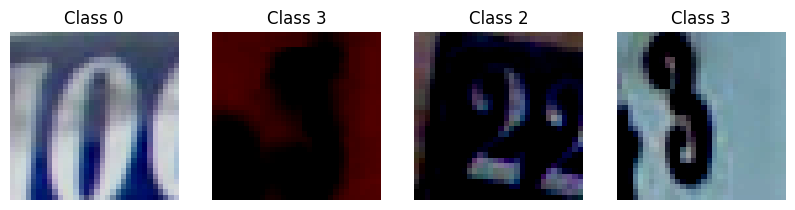

In [ ]:
images, labels = next(iter(train_loader))

# Show first 4 images
fig, axes = plt.subplots(1, 4, figsize=(10, 4))
for i in range(4):
  img = images[i].permute(1, 2, 0).numpy()
  #img = np.clip(img * 0.229 + 0.485, 0, 1)  # unnormalize for display
  axes[i].imshow(img)
  axes[i].set_title(f"Class {labels[i].item()}")
  axes[i].axis('off')
plt.show()

**Answer the following Questions:**

<font color="red">**1. How is SVHN fundamentally harder than MNIST?**</font>
<br>
<font color="red">
SVHN is fundamentally harder than MNIST because SVHN digits come from a real world scenes and contain a lot of visual clutter. The digits in SVHN appear in different colors, lighting conditions, and backgrounds, and they are not always centered. In contrast, MNIST images are clean, grayscale, centered, and written on a uniform background. This makes MNIST much easier to classify because there is very little noise or variation.
</font>
<br>

<font color="red">**2. Which preprocessing or architectural choices become necessary because of this difference?**</font>
<br>
<font color="red">
Because SVHN images are more complex, stronger preprocessing and a more powerful model is needed. Color normalization is important because SVHN images are RGB and have varying lighting. Also data augmentation helps the model generalize better. Architecturally, deeper CNNs with pooling layers are needed to increase the receptive field so the network can separate digits from background clutter. Dropout or other regularization methods are also useful to reduce overfitting caused by the higher complexity of the data.
</font>


### CNN Architecture Design

We will design a convolutional neural network (inspired by AlexNet) for digit classification.
The network consists of **three convolutional feature-extraction stages**, followed by a **two-layer fully connected classifier**.

Your architecture must follow the structure below:

- Convolutional Layer with 32 output channels, kernel size = 3×3, stride = 1, padding = 1
- ReLU activation function
- MaxPooling Layer with a kernel size of 3×3 and a stride of 2

- Convolutional Layer with 64 output channels, kernel size = 3×3, stride = 1, padding = 1
- ReLU activation function.
- Convolutional Layer with 128 output channels, kernel size = 3×3, stride = 1, padding = 1

- ReLU activation function.

- MaxPooling Layer with a kernel size of 3×3 and a stride of 2.

- Dropout Layer  with a dropout probability of 0.5.

- Fully Connected Layer with output size of 128.

- ReLU activation function

- Dropout Layer  with a dropout probability of 0.5.

- Fully Connected Layer with output size of 10 (for the 10 digit classes, 0–9).



In [ ]:
# TODO: Define the CNN architecture

class SVHN_CNN(nn.Module):
    def __init__(self, num_classes=10):
        #TODO: Implement
        super(SVHN_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=1)
        self.relu3 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.dropout = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 7 * 7, 128)
        self.relu4 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)


    def forward(self, x):
       #TODO: Implement
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.maxpool2(x)
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x


**Answer the following Questions:**

<font color="red">**1.** Which part(s) of your CNN most strongly influence receptive field size?</font>  
<br>
<font color="red">
The parts that most strongly influence receptive field size in our CNN are the **convolution** layers and, more strongly, the **max pooling** layers. Even though the convolution layers preserve the spatial dimensions due to padding, each convolution operates on neighboring pixels, so deeper neurons are influenced by a larger region of the input image, causing the receptive field to grow gradually.
<br>
The max pooling layers increase the receptive field more significantly because they both aggregate information over a larger window and use a stride greater than one. This means that each pooled activation corresponds to a larger area in the original image, and subsequent layers build on this enlarged region.
<br>
In contrast, the fully connected layers do not affect the spatial receptive field, since they operate after flattening and only combine the features that were already extracted by the convolution and pooling layers.
<br>
</font>

<font color="red">**2.** Why does receptive field matter for recognizing digits embedded in cluttered scenes?</font>
<br>
<font color="red">
<br>
Receptive field is important for recognizing digits in cluttered scenes because the network needs to see not only small pixel details but also the larger structure of the digit. When the receptive field is bigger, neurons can combine information from different parts of the image and understand which pixels belong to the digit and which belong to the background.
<br>
A larger receptive field also makes the network less sensitive to small translations and small changes in position. This helps the model generalize better because the same digit can appear in slightly different locations inside a cluttered image. As a result, the network focuses more on the overall shape of the digit and achieves better recognition performance.
</font>


Now we will setup all training parameters and train the model.

Your tasks in this section are to create an instance of the model and choose and explain your choice of optimizer and loss function.
3. Fill the missing code in the training function.
4. Train the model for ~6 epochs on the training set (in colab CPU should take ~30 mins).

In [ ]:
# TODO: Implement
def init_xavier(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        init.xavier_uniform_(m.weight)
        if m.bias is not None:
            init.zeros_(m.bias)
model = SVHN_CNN(num_classes=10).to(device)
model.apply(init_xavier)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Now, fill in the missing code for the training function and train the model for 10 epochs.

In [ ]:
#TODO fill the missing code in the training function

def train_model(model, train_loader, criterion, optimizer, device, num_epochs=10):
  model.to(device)

  for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
      # images, labels = images.to(device), labels.to(device) #for GPU
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      _, predicted = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")


In [ ]:
#TODO: Implement Training
epochs = 10
train_model(model, train_loader, criterion, optimizer, device, num_epochs=epochs)

Epoch [1/10] Train Loss: 1.0606, Train Acc: 65.30%
Epoch [2/10] Train Loss: 0.6088, Train Acc: 81.36%
Epoch [3/10] Train Loss: 0.5177, Train Acc: 84.48%
Epoch [4/10] Train Loss: 0.4626, Train Acc: 86.31%
Epoch [5/10] Train Loss: 0.4222, Train Acc: 87.55%
Epoch [6/10] Train Loss: 0.3946, Train Acc: 88.25%
Epoch [7/10] Train Loss: 0.3698, Train Acc: 89.04%
Epoch [8/10] Train Loss: 0.3528, Train Acc: 89.58%
Epoch [9/10] Train Loss: 0.3371, Train Acc: 90.04%
Epoch [10/10] Train Loss: 0.3223, Train Acc: 90.39%


The following function evaluates a given model on the loaded test set. Use it to evaluate your trained model on the test set loader.

In [ ]:
def evaluate_model(model, loader):
  model.eval()
  correct, total = 0, 0

  with torch.no_grad():
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = outputs.max(1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  accuracy = 100 * correct / total
  return accuracy

In [ ]:
test_accuracy = evaluate_model(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 92.33%


**Answer the following Question:**

<font color="red">1. If training loss drops very quickly in the early epochs, is that always a good sign — or could it signal a potential problem?</font>
</br>
</br>
<font color="red">
A very fast drop in training loss is not always a good sign , because it might say that the model is memorizing instead of learning useful patterns (Overfitting), where the model learns the training data too well and does not generalize to new data. Therefore, training loss should always be checked together with validation or test results.
</font>

### Visualizing Feature Maps

To deepen our understanding of what the CNN learns, we will visualize **feature maps** (activations) produced inside the network when passing a single image forward.

Feature maps show *where* the network detects edges, curves, textures, and higher-level structures.  

In this section, select one test image, pass it through the CNN and finally visualize activation maps from different convolution layers.


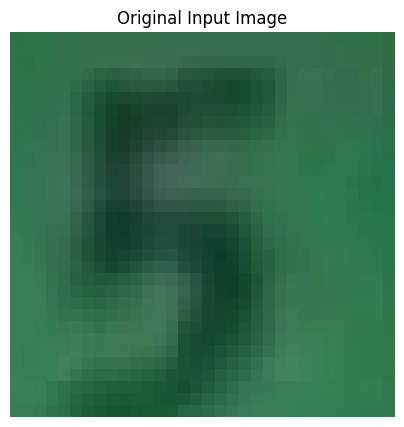

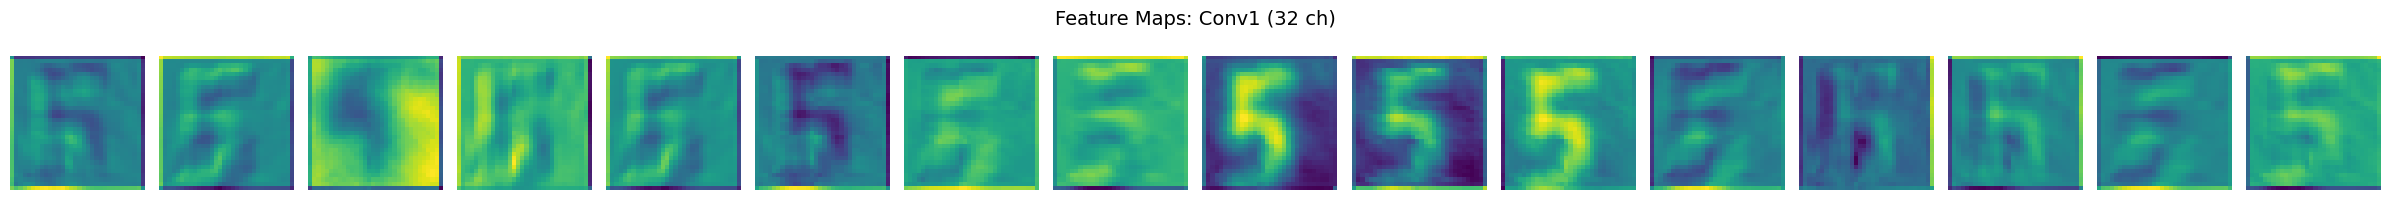

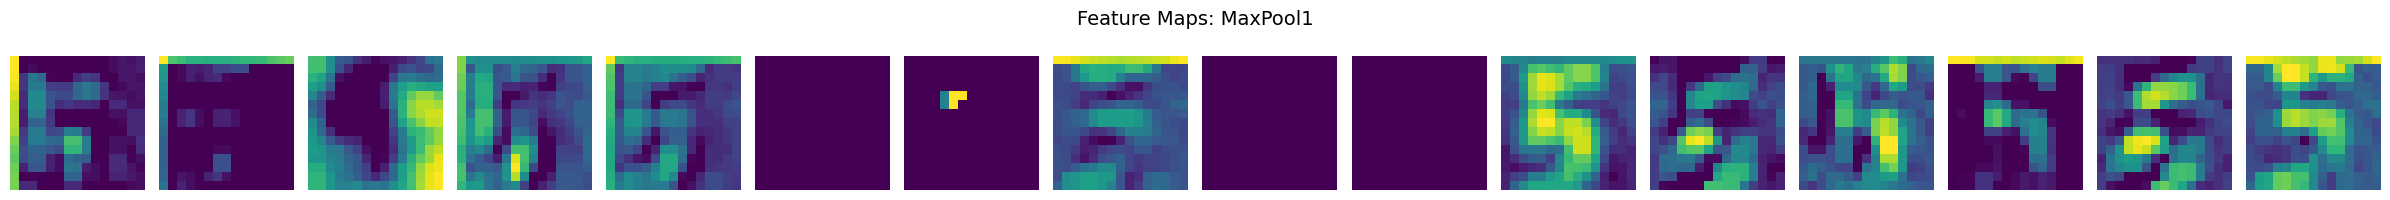

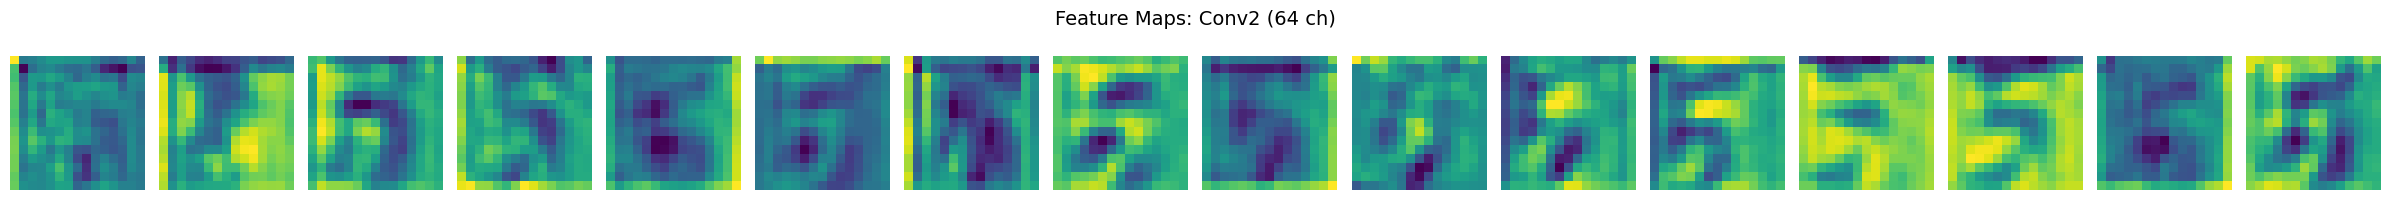

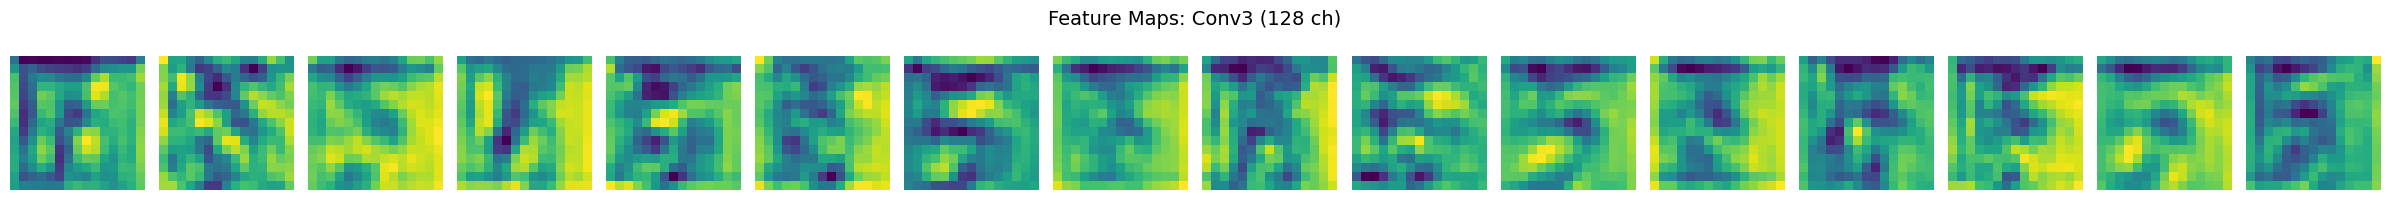

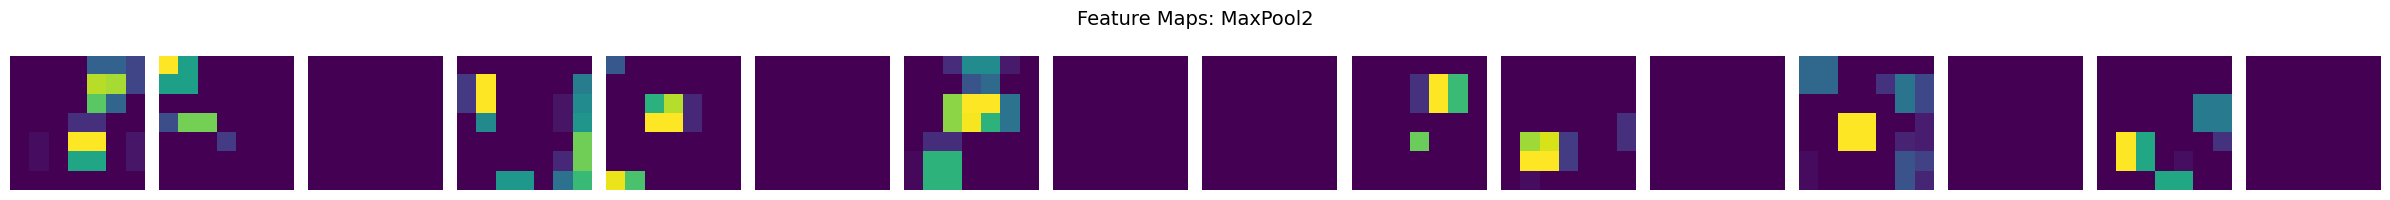

In [ ]:
# 1. Helper function to show images
def denormalize(tensor):
    """Reverts the normalization: (image * 0.5) + 0.5"""
    return tensor * 0.5 + 0.5

def visualize_feature_maps(model, input_image):
    model.eval() # Set to evaluation mode

    # Add batch dimension: (3, 32, 32) -> (1, 3, 32, 32)
    x = input_image.unsqueeze(0)

    device = next(model.parameters()).device
    x = x.to(device)

    feature_maps = {}

    x = model.conv1(x)
    feature_maps['Conv1 (32 ch)'] = x
    x = model.relu1(x)
    x = model.maxpool1(x)
    feature_maps['MaxPool1'] = x

    x = model.conv2(x)
    feature_maps['Conv2 (64 ch)'] = x
    x = model.relu2(x)

    x = model.conv3(x)
    feature_maps['Conv3 (128 ch)'] = x
    x = model.relu3(x)
    x = model.maxpool2(x)
    feature_maps['MaxPool2'] = x

    # First, plot the original input image
    plt.figure(figsize=(5, 5))
    original_img = denormalize(input_image).permute(1, 2, 0).numpy()
    plt.imshow(original_img)
    plt.title("Original Input Image")
    plt.axis('off')
    plt.show()

    for layer_name, f_map in feature_maps.items():
        f_map = f_map.squeeze(0).detach().cpu()

        num_channels = f_map.shape[0]

        # We will visualize up to 16 channels per layer to keep the plot readable
        num_to_plot = min(16, num_channels)

        fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 1.5, 2))
        fig.suptitle(f"Feature Maps: {layer_name}", fontsize=14)

        for i in range(num_to_plot):
            ax = axes[i]
            img = f_map[i, :, :]
            ax.imshow(img, cmap='viridis')
            ax.axis('off')

        plt.tight_layout()
        plt.show()


dataiter = iter(test_loader)
images, labels = next(dataiter)

test_image = images[0]

visualize_feature_maps(model, test_image)

### Architecture Modification Experiment

Modify your `SVHN_CNN` model by removing or relocating different kinds of layers.

1. Propose two significant architectural changes.
2. Implement your modified models as
  - `SVHN_CNN_v2`
  - `SVHN_CNN_v3`
3. Train and evaluate both models using the same setup as the original.

In [ ]:
# TODO: Implemnt
class SVHN_CNN_v2(nn.Module):
    def __init__(self, num_classes=10):
        #TODO: Implement
        super(SVHN_CNN_v2, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=1)
        self.relu3 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 7 * 7, 128)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)


    def forward(self, x):
       #TODO: Implement
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.maxpool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.fc2(x)
        return x


In [ ]:
class SVHN_CNN_v3(nn.Module):
    def __init__(self, num_classes=10):
        #TODO: Implement
        super(SVHN_CNN_v3, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout2d(0.5)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=1)
        self.relu3 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.dropout2 = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 7 * 7, 128)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)


    def forward(self, x):
       #TODO: Implement
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.maxpool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x


In [ ]:
v2 = SVHN_CNN_v2(num_classes=10).to(device)
v2.apply(init_xavier)
optimizer_v2 = optim.Adam(v2.parameters(), lr=1e-3)
train_model(v2, train_loader, criterion, optimizer_v2, device, num_epochs=epochs)
test_accuracy_v2 = evaluate_model(v2, test_loader)
print(f"Test Accuracy v2: {test_accuracy_v2:.2f}%")

Epoch [1/10] Train Loss: 0.7608, Train Acc: 76.50%
Epoch [2/10] Train Loss: 0.3673, Train Acc: 89.36%
Epoch [3/10] Train Loss: 0.2951, Train Acc: 91.36%
Epoch [4/10] Train Loss: 0.2502, Train Acc: 92.64%
Epoch [5/10] Train Loss: 0.2173, Train Acc: 93.67%
Epoch [6/10] Train Loss: 0.1864, Train Acc: 94.55%
Epoch [7/10] Train Loss: 0.1591, Train Acc: 95.24%
Epoch [8/10] Train Loss: 0.1343, Train Acc: 95.93%
Epoch [9/10] Train Loss: 0.1158, Train Acc: 96.47%
Epoch [10/10] Train Loss: 0.0976, Train Acc: 96.94%
Test Accuracy v2: 90.19%


In [ ]:
v3 = SVHN_CNN_v3(num_classes=10).to(device)
v3.apply(init_xavier)
optimizer_v3 = optim.Adam(v3.parameters(), lr=1e-3)
train_model(v3, train_loader, criterion, optimizer_v3, device, num_epochs=epochs)
test_accuracy_v3 = evaluate_model(v3, test_loader)
print(f"Test Accuracy v3: {test_accuracy_v3:.2f}%")

Epoch [1/10] Train Loss: 1.4037, Train Acc: 51.87%
Epoch [2/10] Train Loss: 0.8412, Train Acc: 72.16%
Epoch [3/10] Train Loss: 0.7163, Train Acc: 76.43%
Epoch [4/10] Train Loss: 0.6254, Train Acc: 80.02%
Epoch [5/10] Train Loss: 0.5764, Train Acc: 81.75%
Epoch [6/10] Train Loss: 0.5484, Train Acc: 82.52%
Epoch [7/10] Train Loss: 0.5239, Train Acc: 83.21%
Epoch [8/10] Train Loss: 0.4958, Train Acc: 84.34%
Epoch [9/10] Train Loss: 0.4764, Train Acc: 85.05%
Epoch [10/10] Train Loss: 0.4557, Train Acc: 85.71%
Test Accuracy v3: 89.96%


## Question 2: The One Hundred Layers Tiramisu (45 Points)


In this question we explore the problem of **semantic segmentation**: assigning a class label to **every pixel** in an image.

We base our work on the paper:

> Jégou, S., Drozdzal, M., Vázquez, D., Romero, A., & Bengio, Y. (2017).  
> **The One Hundred Layers Tiramisu: Fully Convolutional DenseNets for Semantic Segmentation.**  
> *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition Workshops (CVPRW)*.  
> [[PDF link](https://arxiv.org/pdf/1611.09326.pdf)]


For those interested, I highly recommend reading the paper to expand your understanding of DenseNet-based architectures and generally in deep learning literature. That said, reading it is **not required** — the tools and concepts needed for this assignment are introduced gradually throughout the steps.

Our goal is to replicate the architecture of DenseNets described in the paper, aiming for comparable behaviour while using a **smaller variant** (e.g., DenseNet-67 instead of DenseNet-103) to ensure runtime feasibility on your GPUs.

We work with the **CamVid** dataset, which consists of urban driving scenes captured from a moving vehicle. Each image is paired with a pixel-wise annotation map indicating semantic classes such as road, sidewalk, building, sky, tree, fence, poles, traffic signs or lights, vehicles, pedestrians, and bicyclists.

Conceptually, semantic segmentation transforms an image into a **grid of classification tasks** — one small prediction problem per pixel — requiring the network to recognize objects and localize them throughout the scene.


### Data Loading & Preprocessing

Before building the model, we must ensure that the dataset is represented in a form a neural network can learn from.

Let:
- $X$ denote the RGB input images from CamVid.
- $Y$ denote the corresponding color-coded annotation masks, where each pixel encodes a semantic class via an RGB value.

The raw CamVid annotations contain **over 30 distinct colors**, including rare and fine-grained categories.  
To make learning tractable and consistent with common practice, we collapse these into a compact set of **11 semantic classes**, and assign all remaining labels to a single **void class**, which is ignored during training.

In this section we will:

1. Define or load the RGB-to-label mapping.
2. Convert each colored mask into a 2D array of integer class IDs.
3. Visualize sample inputs and their mapped labels to verify correctness.

With this mapping in place, segmentation becomes a **pixel-wise classification task** over the label space $\{0, \dots, C-1\}$, rather than operating directly on raw RGB annotation images.


We will use the **CamVid dataset**, which contains street-scene RGB images and their corresponding pixel-wise annotations.  
Please upload the provided `CamVid.zip` dataset to your own google drive. Then, run the following cells by mounting to your drive and unzipping the data.
The archive will be automatically extracted into `/content/CamVid/`.

> `CamVid.zip` is provided to you in `DL-HW2.zip`


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/CamVid.zip"  # wherever you uploaded it
extract_root = "/content/drive/MyDrive/CamVid"

os.makedirs(extract_root, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_root)

print("Extracted to Drive:", extract_root)
!ls "/content/drive/MyDrive/CamVid"

Extracted to Drive: /content/drive/MyDrive/CamVid
class_dict.csv	test	     train	   val
__MACOSX	test_labels  train_labels  val_labels


CamVid annotations are stored as **RGB color masks**, where each distinct color corresponds to a semantic category.  
To train a segmentation model, we must convert these colors into **integer class IDs**.

The mapping used here collapses ~32 original colors into **11 trainable categories** (Sky, Building, Road, etc.), with a separate **Void class** assigned label 255 and excluded from the loss.

Below we define:
- an RGB-to-label mapping,
- a PyTorch dataset class that:
  - reads images and masks,
  - applies cropping and flipping,
  - converts masks into numeric class IDs,
  - normalizes images.

In [33]:
# Data Loading & Preprocessing

# Convert 32 -> 11 CamVid mapping: RGB -> label name
RGBLabel2LabelName = {
    (128, 128, 128): "Sky",

    (0,   128,  64): "Building",
    (128,   0,   0): "Building",
    (64,  192,   0): "Building",
    (64,    0,  64): "Building",
    (192,   0, 128): "Building",

    (192, 192, 128): "Pole",
    (0,     0,  64): "Pole",

    (128,  64, 128): "Road",
    (128,   0, 192): "Road",
    (192,   0,  64): "Road",

    (0,     0, 192): "Sidewalk",
    (64,  192, 128): "Sidewalk",
    (128, 128, 192): "Sidewalk",

    (128, 128,   0): "Tree",
    (192, 192,   0): "Tree",

    (192, 128, 128): "SignSymbol",
    (128, 128,  64): "SignSymbol",
    (0,    64,  64): "SignSymbol",

    (64,   64, 128): "Fence",

    (64,    0, 128): "Car",
    (64,  128, 192): "Car",
    (192, 128, 192): "Car",
    (192,  64, 128): "Car",
    (128,  64,  64): "Car",

    (64,   64,   0): "Pedestrian",
    (192, 128,  64): "Pedestrian",
    (64,    0, 192): "Pedestrian",
    (64,  128,  64): "Pedestrian",

    (0,   128, 192): "Bicyclist",
    (192,   0, 192): "Bicyclist",

    (0,     0,   0): "Void"
}

# Define the 11 train classes and the void index
TRAIN_CLASSES = [
    "Sky",
    "Building",
    "Pole",
    "Road",
    "Sidewalk",
    "Tree",
    "SignSymbol",
    "Fence",
    "Car",
    "Pedestrian",
    "Bicyclist"
]

LABEL_NAME_TO_ID = {name: i for i, name in enumerate(TRAIN_CLASSES)}
VOID_LABEL_NAME = "Void"
VOID_INDEX = 255


class CamVidDataset(Dataset):
    """
    CamVid dataset loader that:
    - reads RGB images from e.g. CamVid/train
    - reads RGB masks from e.g. CamVid/train_labels
    - uses the RGBLabel2LabelName mapping to:
        32+ RGB colors -> 11 train classes (0..10) + Void (255)
    - applies normalization and simple augmentations

    Output:
      image: float tensor (3, H, W), normalized (ImageNet stats)
      mask:  long tensor (H, W) with values in {0..10, 255}
             where 255 is the ignore_index for the loss.
    """

    def __init__(self,
                 image_dir,
                 mask_dir,
                 crop_size=(224, 224),
                 is_train=True):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.is_train = is_train
        self.crop_h, self.crop_w = crop_size

        # Collect image paths
        self.image_paths = sorted(
            glob(os.path.join(image_dir, "*.png")) +
            glob(os.path.join(image_dir, "*.jpg")) +
            glob(os.path.join(image_dir, "*.jpeg"))
        )
        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {image_dir}")

        # Build corresponding mask paths (same filename, different folder)
        self.mask_paths = []
        for p in self.image_paths:
            base = os.path.basename(p)
            name, ext = os.path.splitext(base)


            candidate = os.path.join(mask_dir, name + "_L" + ext)
            if os.path.exists(candidate):
                self.mask_paths.append(candidate)
            else:
                candidate2 = os.path.join(mask_dir, base)
                if not os.path.exists(candidate2):
                    raise FileNotFoundError(
                        f"Could not find mask for image {p}. "
                        f"Tried: {candidate} and {candidate2}"
                    )
                self.mask_paths.append(candidate2)

        # Build color -> train_id mapping from RGBLabel2LabelName
        self.num_classes = len(TRAIN_CLASSES)
        self.train_id_to_name = TRAIN_CLASSES
        self.void_index = VOID_INDEX

        self.color_to_train_id = {}
        for (r, g, b), label_name in RGBLabel2LabelName.items():
            if label_name == VOID_LABEL_NAME:
                # Void will be handled by default (everything starts as VOID_INDEX)
                continue
            train_id = LABEL_NAME_TO_ID[label_name]
            self.color_to_train_id[(r, g, b)] = train_id

        # Normalization
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image & mask as numpy arrays
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")  # color-coded mask

        img = np.array(img, dtype=np.uint8)   # (H,W,3)
        mask = np.array(mask, dtype=np.uint8) # (H,W,3)

        # random data augmentation
        if self.is_train:
            img, mask = self.random_crop(img, mask, self.crop_h, self.crop_w)
            img, mask = self.random_horizontal_flip(img, mask)

        # Convert color mask -> class index mask (0..10, 255)
        class_mask = self.rgb_to_class_indices(mask)  # (H,W), int64

        # Convert image to tensor and normalize
        img = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0  # (3,H,W)
        img = (img - self.mean) / self.std

        class_mask = torch.from_numpy(class_mask).long()  # (H,W)

        return img, class_mask

    def rgb_to_class_indices(self, mask_rgb):
        """
        mask_rgb: (H,W,3) uint8
        returns: (H,W) int64 with values in {0..num_classes-1, void_index}

        Any pixel whose color is not in RGBLabel2LabelName or not in the 11
        train classes is assigned void_index (255), same idea as CamVidGray.
        """
        h, w, _ = mask_rgb.shape
        class_mask = np.full((h, w), fill_value=self.void_index, dtype=np.int64)

        # iterate over all known label colors
        for (r, g, b), train_id in self.color_to_train_id.items():
            matches = (
                (mask_rgb[:, :, 0] == r) &
                (mask_rgb[:, :, 1] == g) &
                (mask_rgb[:, :, 2] == b)
            )
            class_mask[matches] = train_id

        # Any remaining colors (including weird mislabels) stay as void_index
        return class_mask

    @staticmethod
    def random_crop(img, mask, crop_h, crop_w):
        """Randomly crop the same region from image and mask."""
        H, W, _ = img.shape
        if (H <= crop_h) or (W <= crop_w):
            # Fallback: center crop if image is smaller than the crop
            top = max(0, (H - crop_h) // 2)
            left = max(0, (W - crop_w) // 2)
        else:
            top = np.random.randint(0, H - crop_h + 1)
            left = np.random.randint(0, W - crop_w + 1)

        img_crop = img[top:top + crop_h, left:left + crop_w, :]
        mask_crop = mask[top:top + crop_h, left:left + crop_w, :]

        return img_crop, mask_crop

    @staticmethod
    def random_horizontal_flip(img, mask, p=0.5):
        """Randomly flip image and mask horizontally with probability p."""
        if np.random.rand() < p:
            img = np.ascontiguousarray(img[:, ::-1, :])   # flip width
            mask = np.ascontiguousarray(mask[:, ::-1, :])
        return img, mask

We now instantiate our dataset class over the train/validation splits and wrap them with PyTorch `DataLoader`s for batching.

We verify:
- tensor shapes,
- expected number of classes,
- that label values fall within `{0..10, 255}`.

In [34]:
# Base directory
base_dir = "/content/drive/MyDrive/CamVid"

train_images = f"{base_dir}/train"
train_masks  = f"{base_dir}/train_labels"

val_images   = f"{base_dir}/val"
val_masks    = f"{base_dir}/val_labels"

test_images  = f"{base_dir}/test"
test_masks   = f"{base_dir}/test_labels"

# Create datasets
train_dataset = CamVidDataset(
    image_dir=train_images,
    mask_dir=train_masks,
    crop_size=(224, 224),
    is_train=True
)

val_dataset = CamVidDataset(
    image_dir=val_images,
    mask_dir=val_masks,
    crop_size=(224, 224),
    is_train=False
)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=3, shuffle=False, num_workers=2)

# Quick sanity check: shapes + labels
imgs, masks = next(iter(train_loader))
print("Images:", imgs.shape)   # (B,3,H,W)
print("Masks:", masks.shape)   # (B,H,W)
print("Num classes:", train_dataset.num_classes)
print("Unique labels in this batch:", torch.unique(masks))

Images: torch.Size([3, 3, 224, 224])
Masks: torch.Size([3, 224, 224])
Num classes: 11
Unique labels in this batch: tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8, 255])


To ensure that preprocessing worked as expected, we decode the class IDs back into colors and visualize:
- the input RGB image,
- the processed 11-class segmentation mask,
- an overlay.

This provides a quick visual confirmation that label mapping and crops are applied correctly.

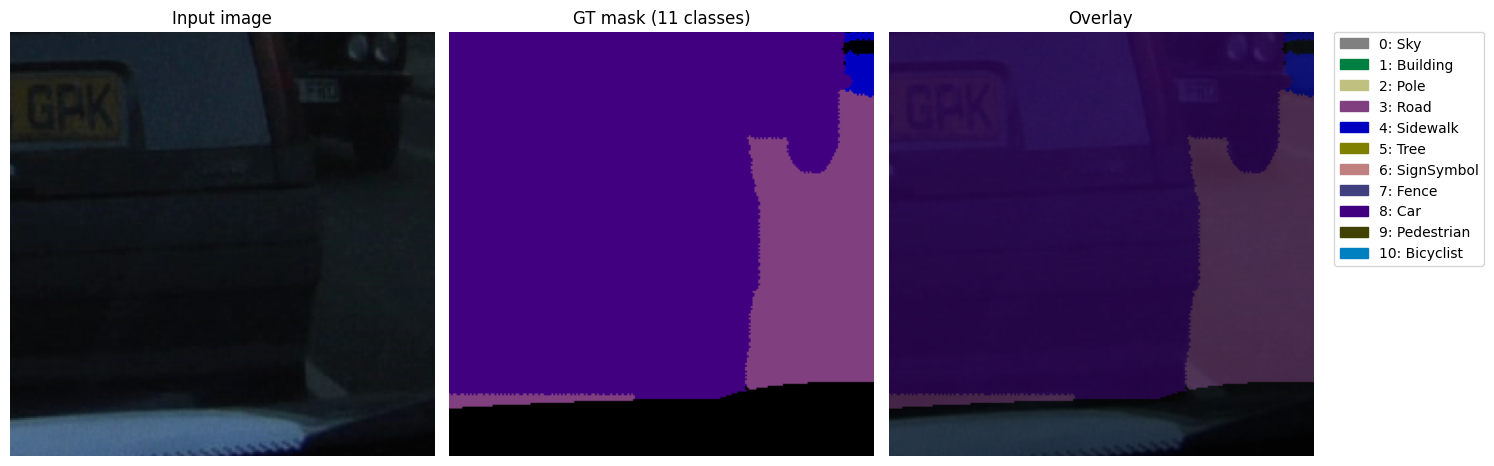

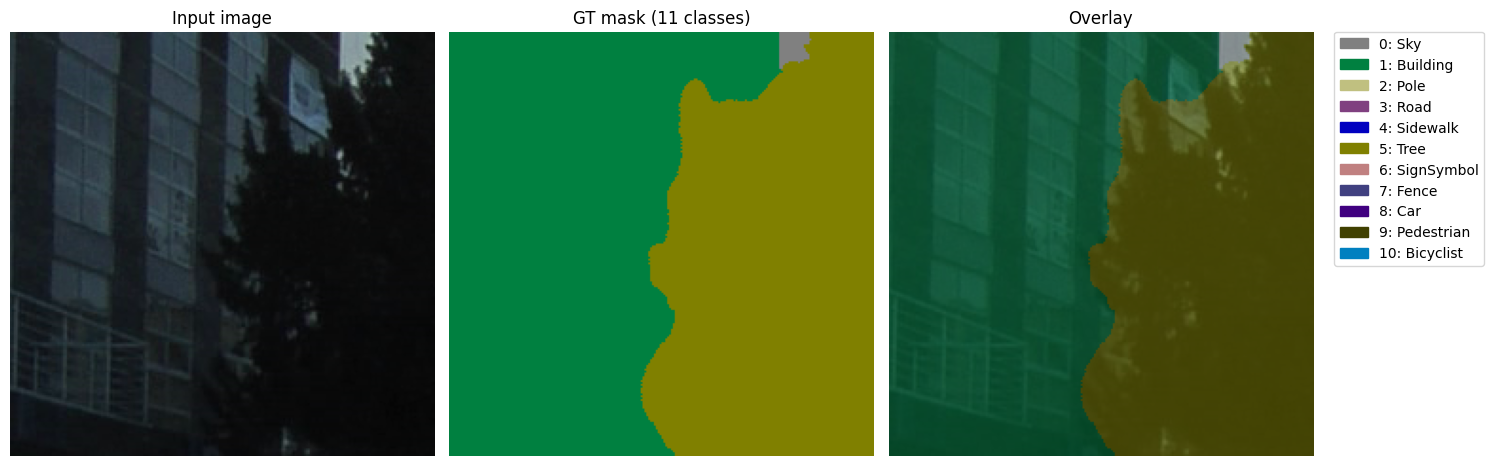

In [35]:
# Build a display color for each of the 11 train classes:
# take the first RGB that maps to that label.
TRAIN_ID_TO_COLOR = {}
for (r, g, b), label_name in RGBLabel2LabelName.items():
    if label_name == VOID_LABEL_NAME:
        continue
    train_id = LABEL_NAME_TO_ID[label_name]
    if train_id not in TRAIN_ID_TO_COLOR:
        TRAIN_ID_TO_COLOR[train_id] = (r, g, b)


def decode_class_mask(class_mask, train_id_to_color, void_index=VOID_INDEX):
    """
    class_mask: (H,W) int64 in {0..C-1, void_index}
    returns: (H,W,3) uint8 color mask for visualization
    """
    h, w = class_mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for train_id, color in train_id_to_color.items():
        color_mask[class_mask == train_id] = np.array(color, dtype=np.uint8)

    # void pixels stay black (0,0,0);
    return color_mask


def visualize_camvid_sample(dataset, idx=0):
    """
    Show:
      - input image
      - merged 11-class mask
      - overlay + legend (class key)
    """
    img, mask = dataset[idx]  # img: normalized tensor, mask: (H,W) long

    # Denormalize for display
    img_np = img.clone()
    img_np = (img_np * dataset.std + dataset.mean).clamp(0, 1)
    img_np = img_np.numpy().transpose(1, 2, 0)  # (H,W,3), [0,1]

    mask_np = mask.numpy()
    color_mask = decode_class_mask(mask_np, TRAIN_ID_TO_COLOR, VOID_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_np)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    axes[1].imshow(color_mask)
    axes[1].set_title("GT mask (11 classes)")
    axes[1].axis("off")

    axes[2].imshow(img_np)
    axes[2].imshow(color_mask, alpha=0.5)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    # Legend / key
    patches = [
        mpatches.Patch(
            color=np.array(TRAIN_ID_TO_COLOR[i]) / 255.0,
            label=f"{i}: {TRAIN_CLASSES[i]}"
        )
        for i in range(len(TRAIN_CLASSES))
    ]
    axes[2].legend(handles=patches, bbox_to_anchor=(1.05, 1.0),
                   loc="upper left", borderaxespad=0.)

    plt.tight_layout()
    plt.show()


# Try a couple of samples
visualize_camvid_sample(train_dataset, idx=0)
visualize_camvid_sample(train_dataset, idx=10)

### Network Architecture Overview

We now design the architecture of our DenseNet model — a fully convolutional encoder–decoder network tailored for semantic segmentation.

<p align="center">
  <img src="https://raw.githubusercontent.com/SimJeg/FC-DenseNet/cf2375bf9f6ed20ba029a5ee540261aad89732d5/DenseNet.jpg" width="650"/>
</p>

Conceptually, the network processes the image through a **downsampling path** (encoder), reaches a compressed representation (bottleneck), and then reconstructs a dense prediction map through an **upsampling path** (decoder). Lateral skip connections link encoder features to their corresponding decoder levels, ensuring fine spatial detail is preserved.

The architecture is built from the following components:

**(a) Dense Layer**

**(b) Dense Block**

**(c) Transition Down**

**(d) Transition Up**

**(e) Bottleneck Block**

**(f) Final Classifier**

We next implement each component in modular form and assemble them into a complete FC-DenseNet for CamVid segmentation.


#### **(a) Dense Layer**

The basic computational unit in DenseNet is the **dense layer**.  
Each layer receives as input **all previous feature maps** in the block, applies:

$$
\text{BN} \rightarrow \text{ReLU} \rightarrow 3 \times 3 \text{Conv}
$$

and produces `k` new feature maps (the **growth rate**).  
These outputs are concatenated with the input along the channel axis.


In [36]:
class DenseLayer(nn.Module):
    """
    BN -> ReLU -> 3x3 Conv -> Dropout,
    then concatenate input and output feature maps.
    """
    def __init__(self, in_channels, growth_rate, drop_prob=0.2):
        super(DenseLayer, self).__init__()
        self.net = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1),
            nn.Dropout2d(drop_prob)
        )

    def forward(self, x):
        new_features = self.net(x)
        return torch.cat([x, new_features], dim=1)


#### **(b) Dense Block**  


A dense block stacks several dense layers sequentially.  
Each layer receives **all feature maps from previous layers** and contributes new ones:

$$
C_{\text{out}} = C_{\text{in}} + L \cdot k
$$

<p align="center">
  <img src="https://raw.githubusercontent.com/SimJeg/FC-DenseNet/master/DenseBlock.jpg" width="300" height="600"/>
</p>

This connectivity pattern promotes feature reuse, stabilizes gradients, and forms the core building unit of our network.


In [37]:
class DenseBlock(nn.Module):
    """
    A sequence of DenseLayer modules.
    Input channels grow by `growth_rate` at each layer.
    """
    def __init__(self, in_channels, num_layers, growth_rate, drop_prob=0.2):
        super(DenseBlock, self).__init__()

        layers = []
        current_channels = in_channels

        for i in range(num_layers):
            layers.append(DenseLayer(current_channels, growth_rate, drop_prob))
            current_channels += growth_rate

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

#### **(c) Transition Down**


At the end of each encoder stage, we reduce spatial resolution:

$$
\text{BN} \rightarrow \text{ReLU} \rightarrow 1\times1\text{ Conv} \rightarrow \text{Dropout} \rightarrow \text{MaxPool}(2)
$$

This halves width and height while keeping channels unchanged.


In [38]:
class TransitionDown(nn.Module):
    """
    BN + ReLU + 1x1 Conv + Dropout + MaxPool(2x2)
    """
    def __init__(self, in_channels, drop_prob=0.2):
        super(TransitionDown, self).__init__()
        self.net = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, in_channels, kernel_size=1),
            nn.Dropout2d(drop_prob),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.net(x)

#### **(d) Transition Up**  


In the decoder, we restore resolution using learned upsampling via transposed convolution:

$$
\text{ConvTranspose}(3 \times 3, \text{stride}=2)
$$

which doubles spatial resolution before concatenation with skip features.


In [39]:
class TransitionUp(nn.Module):
    """
    Transposed convolution for upsampling by a factor of 2.
    """
    def __init__(self, in_channels, out_channels):
        super(TransitionUp, self).__init__()
        self.transposed_conv = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1
        )

    def forward(self, x):
        return self.transposed_conv(x)

#### **(e) Bottleneck Block**


At the deepest level, the network operates at the lowest spatial resolution but highest channel width.

A final dense block processes this information before reconstruction begins in the decoder.


### Our FC-DenseNet-lite Architecture

We implement a compact FC-DenseNet architecture inspired by *The One Hundred Layers Tiramisu*.
All convolutional **dense layers** use growth rate $k = 16$. At each dense block:

- Input has $m$ feature maps.
- The block has $n$ layers.
- Each layer adds $k$ new feature maps.
- The output of the block therefore has $m + n \cdot k$ feature maps (because we concatenate all newly created features with the input).

Transition Down (TD) blocks keep the number of channels $m$ but downsample in space via 2×2 max pooling.
Transition Up (TU) blocks use a 3×3 transposed convolution with stride 2 to upsample.

Our **homework architecture ("FC-DenseNet-lite")** is defined as follows:

- Input: RGB image, $m = 3$
- Initial 3×3 convolution: $m = 48$

</br>

**Downsampling path (encoder)**

- Dense Block 1: 4 layers  
  $m = 48 + 4 \cdot 16 = 112$  
  + Transition Down → spatial size /2, channels stay 112
- Dense Block 2: 5 layers  
  $m = 112 + 5 \cdot 16 = 192$  
  + Transition Down → channels 192
- Dense Block 3: 7 layers  
  $m = 192 + 7 \cdot 16 = 304$  
  + Transition Down → channels 304
- Dense Block 4: 10 layers  
  $m = 304 + 10 \cdot 16 = 464$  
  + Transition Down → channels 464

</br>


**Bottleneck**

- Dense Block (bottleneck): 15 layers  
  $m = 464 + 15 \cdot 16 = 704$

</br>


**Upsampling path (decoder)**

At each level, we:
1. Apply a Transition Up (TU) to upsample the current feature maps.
2. Concatenate with the skip connection from the corresponding encoder level.
3. Apply a dense block at that resolution.

We use symmetric numbers of layers in the decoder:

- TU from bottleneck + skip from Dense Block 4 $\to$ Dense Block (10 layers)
- TU + skip from Dense Block 3 $\to$ Dense Block (7 layers)
- TU + skip from Dense Block 2 $\to$ Dense Block (5 layers)
- TU + skip from Dense Block 1 $\to$ Dense Block (4 layers)


</br>

**Final classifier**

- 1×1 convolution maps the decoder output to $C = 11$ class logits per pixel.

> We call network `FC-DenseNet67` which is a smaller version of `FC-DenseNet103`, the architecture used in the paper.

In [41]:
class FCDenseNet(nn.Module):
    """
    Fully Convolutional DenseNet for semantic segmentation.
    Uses:
      - initial 3x3 conv
      - sequence of DenseBlock + TransitionDown (encoder)
      - bottleneck DenseBlock
      - sequence of TransitionUp + DenseBlock with skip connections (decoder)
      - final 1x1 conv to class logits
    """

    def __init__(self, in_channels=3, n_classes=11, growth_rate=16, drop_prob=0.2):
        super(FCDenseNet, self).__init__()

        # configs
        self.encoder_layers = [4, 5, 7, 10]
        self.bottleneck_layers = 15
        self.growth_rate = growth_rate
        self.drop_prob = drop_prob

        # Initial 3x3 Conv
        self.init_conv = nn.Conv2d(in_channels, 48, kernel_size=3, padding=1)
        num_channels = 48

        # Encoder
        self.encoder_blocks = nn.ModuleList()
        self.transition_downs = nn.ModuleList()
        self.skip_channel_counts = []

        for num_layers in self.encoder_layers:
            self.encoder_blocks.append(DenseBlock(num_channels, num_layers, growth_rate, drop_prob))
            num_channels += num_layers * growth_rate
            self.skip_channel_counts.append(num_channels)
            self.transition_downs.append(TransitionDown(num_channels, drop_prob))

        # Bottleneck (last layer of the downsampling path)
        self.bottleneck = DenseBlock(num_channels, self.bottleneck_layers, growth_rate, drop_prob)
        new_features_count = self.bottleneck_layers * growth_rate

        # Decoder: Grow image back to original size
        self.decoder_layers = self.encoder_layers[::-1]
        self.reversed_skip_channels = self.skip_channel_counts[::-1]
        self.transition_ups = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()

        for i, num_layers in enumerate(self.decoder_layers):
            self.transition_ups.append(TransitionUp(new_features_count, new_features_count))
            block_input_channels = new_features_count + self.reversed_skip_channels[i]
            self.decoder_blocks.append(DenseBlock(block_input_channels, num_layers, growth_rate, drop_prob))
            new_features_count = num_layers * growth_rate

        # Final Classifier: Map features to 11 classes
        self.classifier = nn.Conv2d(new_features_count, n_classes, kernel_size=1)

    def forward(self, x):
        out = self.init_conv(x)

        # 1. Downsampling Path
        skips = []
        for i in range(len(self.encoder_blocks)):
            out = self.encoder_blocks[i](out)
            skips.append(out)
            out = self.transition_downs[i](out)

        # 2. Bottleneck
        out = self.bottleneck(out)

        # 3. Upsampling Path
        new_features = out[:, -(self.bottleneck_layers * self.growth_rate):, :, :]

        skips = skips[::-1]
        for i in range(len(self.decoder_blocks)):
            up = self.transition_ups[i](new_features)
            out = self.decoder_blocks[i](torch.cat([up, skips[i]], dim=1))
            num_layers = self.decoder_layers[i]
            new_features = out[:, -(num_layers * self.growth_rate):, :, :]

        return self.classifier(new_features)

**Sanity Check!**

Before training, we verify that the model:

- accepts a tensor of shape `(B, 3, H, W)`,
- returns logits of shape `(B, C, H, W)` matching the number of classes.

This ensures that channel propagation, skip concatenation, and upsampling were implemented correctly.


In [42]:
model = FCDenseNet(in_channels=3, n_classes=len(TRAIN_CLASSES), growth_rate=16)
x = torch.randn(1, 3, 224, 224)
y = model(x)
print("Output shape:", y.shape)  # expected: (1, 11, 224, 224)


Output shape: torch.Size([1, 11, 224, 224])


**Answer the following Questions:**

<font color="red">**1. Why do segmentation networks need spatial priors that classification networks can ignore?**
Classification is only about what is in the image, so to a classifier a dog is still a dog whether its at the top, bottom or center of the frame. because it doesnt care about location.
Segmentation is about where, since we are labeling every pixel - the network must know exactly where an object starts and ends. so spatial priors is needed for segmentation networks because spatial priors is like a map tells the network which pixels are neighbors. whithout this map, the network would lose the boundaries of objects and would not know which label goes where.

</font>  


<font color="red">**2. What changes architecturally when we move from "what is in the image?" to "where is it?"**
In classification, the network only answers what is in the image, so it gives one result for the whole image. In segmentation, the network must also know where things are, so it predicts a class for each pixel. To do this, the model keeps the spatial structure, uses an encoder–decoder design, adds upsampling layers to go back to the original size, and uses skip connections to recover details and object boundaries.

</font>

<font color="red">**3. What failure mode would you expect if skip connections were removed from Tiramisu?**
If skip connections are removed from Tiramisu, the decoder would lose access to high resolution spatial information from the encoder. As a result, the model would produce blurry segmentations with inaccurate boundaries and may fail to detect small or thin objects, which leads to poor localization.


</font>  

<font color="red">**4. How do skip connections influence gradient flow and spatial detail recovery?**
Skip connections improve gradient flow by providing direct paths for gradients to reach earlier layers, reducing vanishing gradient problems and stabilizing training. Skip connections also help recover spatial details by transferring high resolution features from the encoder to the decoder, leading to sharper boundaries and more accurate localization in the segmentation output.</font>



### Evaluation & Training

We now train our network on CamVid and assess its performance. Before launching training, we first define **evaluation metrics** suited for semantic segmentation, followed by the standard training procedure we are used to.

#### Evaluation Metrics



Semantic segmentation predictions assign a class to **every pixel**.  
Therefore, our evaluation must measure how well the network labels individual pixels and how well it segments regions belonging to different semantic categories.

**1. Pixel-wise Accuracy**

Pixel accuracy measures the fraction of correctly classified pixels:

$$
\text{PixelAcc} =
\frac{\sum_{(i,j)} \mathbf{1}\left[ \hat{Y}_{ij} = Y_{ij} \right]}
     {\sum_{(i,j)} 1},
$$

where $\hat{Y}_{ij}$ is the predicted label and $Y_{ij}$ is the ground truth at pixel $(i,j)$.

This metric is intuitive and easy to interpret, but can be misleading in imbalanced datasets:
large regions like “road” or “sky” dominate, masking poor performance on rare classes (e.g., pedestrians or signs).

</br>
</br>

**2. Intersection over Union (IoU)**

IoU evaluates segmentation quality by comparing overlap between prediction and ground truth.

For a given class $c$, IoU is:

$$
\text{IoU}_c =
\frac{
|\{\hat{Y} = c\} \cap \{Y = c\}|
}{
|\{\hat{Y} = c\} \cup \{Y = c\}|
}.
$$

IoU penalizes:

- over-segmentation (predicting class $c$ where it does not exist), and  
- under-segmentation (missing regions belonging to class $c$).

To evaluate the entire model, we compute **mean IoU (mIoU)**:

$$
\text{mIoU} = \frac{1}{C}\sum_{c=1}^C \text{IoU}_c,
$$

where $C$ is the number of semantic classes.  
mIoU treats **all classes equally**, even rare ones, making it a standard research metric for segmentation benchmarks including CamVid.

In [43]:
def pixel_accuracy(pred, target, ignore_index=255):
    # Calculate correct predictions for valid pixels then compute the average
    valid_mask = (target != ignore_index)
    correct = (pred == target) & valid_mask
    num_correct = correct.sum().item()
    num_total = valid_mask.sum().item()
    if num_total == 0:
        return 0.0
    return num_correct / num_total


def intersection_and_union(pred, target, num_classes, ignore_index=255):
    mask = (target != ignore_index)
    p = pred[mask]
    t = target[mask]

    intersection = torch.zeros(num_classes, device=pred.device)
    union = torch.zeros(num_classes, device=pred.device)

    for c in range(num_classes):
        # Intersection: True if both pred and target are class 'c'
        inter_c = ((p == c) & (t == c)).sum()
        # Union: True if either pred or target is class 'c'
        union_c = ((p == c) | (t == c)).sum()

        intersection[c] = inter_c
        union[c] = union_c

    return intersection, union


#### Training

We train the network using a **pixel-wise cross-entropy loss**, treating segmentation as per-pixel classification.  
Pixels belonging to the “void” class (255) are ignored:

$$
\mathcal{L} = -\frac{1}{N} \sum_{(i,j)\;|\;Y_{ij}\neq 255}
\log p\left(\, Y_{ij} \mid X \, \right).
$$

Following the original FC-DenseNet paper:

- We use **RMSProp** as the optimizer.
- We include **weight decay (L2 regularization)** to encourage small parameter norms and improve stability.

The RMSProp update maintains a moving average of squared gradients $v$ and performs:

$$
\theta \leftarrow \theta - \alpha \cdot \frac{
\nabla_\theta \mathcal{L}
}{
\sqrt{v + \epsilon}
},
$$

which adaptively scales learning rates per parameter — particularly useful in deep architectures like DenseNets.



**Training Procedure:**

We train the network end-to-end over multiple epochs:

1. Read a mini-batch of input images and ground-truth masks.
2. Forward pass through `FCDenseNet`.
3. Compute loss using cross-entropy (ignoring void pixels).
4. Backpropagate gradients.
5. Update weights using RMSProp.
6. Accumulate accuracy and IoU statistics.
7. Validate periodically to observe generalization.

We repeat this process for 85 epochs, monitoring loss, pixel accuracy, and mIoU to evaluate convergence.

In [45]:
def train_model(model, optimizer, scheduler, criterion, num_epochs):
    best_miou = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss = 0.0
            running_acc = 0.0
            # Initialize IoU components for the whole phase
            total_inter = torch.zeros(len(TRAIN_CLASSES)).to(device)
            total_union = torch.zeros(len(TRAIN_CLASSES)).to(device)

            # Iterate over data
            for images, masks in tqdm(loader, desc=f"{phase.capitalize()}", leave=False):
                images, masks = images.to(device), masks.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass - track history only if in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(images)
                    loss = criterion(outputs, masks)
                    preds = outputs.argmax(dim=1)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item()
                running_acc += pixel_accuracy(preds, masks)

                # mIoU Statistics
                inter, union = intersection_and_union(preds, masks, len(TRAIN_CLASSES))
                total_inter += inter
                total_union += union

            # Compute Epoch Metrics
            epoch_loss = running_loss / len(loader)
            epoch_acc = running_acc / len(loader)
            epoch_miou = (total_inter / (total_union + 1e-10)).mean().item()

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} | "
                  f"mIoU: {epoch_miou:.4f} | Acc: {epoch_acc:.2%}")

            # Step the scheduler at the end of training phase
            if phase == 'train':
                scheduler.step()

            # save best model
            if phase == 'val' and epoch_miou > best_miou:
                best_miou = epoch_miou
                torch.save(model.state_dict(), 'best_model.pth')
                print(f"*** New Best Model Saved (mIoU: {best_miou:.4f}) ***")

    print(f"\nTraining Complete. Best Validation mIoU: {best_miou:.4f}")

In [46]:
model = FCDenseNet(in_channels=3, n_classes=len(TRAIN_CLASSES), growth_rate=16).to(device)
calc_loss = nn.CrossEntropyLoss(ignore_index=VOID_INDEX)
optimizer = optim.RMSprop(model.parameters(), lr=1e-3, weight_decay=1e-4)
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
train_model(model, optimizer, exp_lr_scheduler, calc_loss, num_epochs = 85)


Epoch 1/85
--------------------


Train Loss: 2.3384 | mIoU: 0.1063 | Acc: 40.10%


Val Loss: 1.3969 | mIoU: 0.1702 | Acc: 58.04%
*** New Best Model Saved (mIoU: 0.1702) ***

Epoch 2/85
--------------------


Train Loss: 1.6288 | mIoU: 0.1250 | Acc: 46.49%


Val Loss: 1.2384 | mIoU: 0.1611 | Acc: 58.90%

Epoch 3/85
--------------------


...

Val Loss: 0.6609 | mIoU: 0.3341 | Acc: 78.60%

Epoch 84/85
--------------------


Train Loss: 0.8015 | mIoU: 0.2801 | Acc: 72.15%


Val Loss: 0.6528 | mIoU: 0.3274 | Acc: 78.49%

Epoch 85/85
--------------------


Train Loss: 0.8812 | mIoU: 0.2803 | Acc: 69.90%


Val Loss: 0.6715 | mIoU: 0.3343 | Acc: 78.54%

Training Complete. Best Validation mIoU: 0.3354


Beyond numerical metrics, it is important to **visually inspect** the model’s predictions. In semantic segmentation, this usually means comparing:

1. the input RGB image,
2. the **ground-truth** segmentation mask,
3. the **predicted** segmentation mask.

By looking at these side by side, you can quickly see which classes the model recognizes well, where it struggles, typical failure modes.

Sample a few Images from the test set, and visualize them in comparison to the ground truth and your own prediction.


In [163]:
def visualize_predictions(model, dataset, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            # Pick a random image from test set
            idx = random.randint(0, len(dataset)-1)
            img, mask = dataset[idx]

            # Predict
            output = model(img.unsqueeze(0).to(device))
            pred = output.argmax(dim=1).squeeze(0).cpu().numpy()

            # Denormalize image for display
            img_disp = img.clone()
            img_disp = (img_disp * dataset.std + dataset.mean).clamp(0, 1)
            img_disp = img_disp.numpy().transpose(1, 2, 0)

            mask_np = mask.numpy()

            # Convert masks to colors
            gt_colored = decode_class_mask(mask_np, TRAIN_ID_TO_COLOR)
            pred_colored = decode_class_mask(pred, TRAIN_ID_TO_COLOR)

            axes[i, 0].imshow(img_disp)
            axes[i, 0].set_title("Original Image")
            axes[i, 1].imshow(gt_colored)
            axes[i, 1].set_title("Ground Truth")
            axes[i, 2].imshow(pred_colored)
            axes[i, 2].set_title("Model Prediction")

            for ax in axes[i]: ax.axis('off')

    plt.tight_layout()
    plt.show()

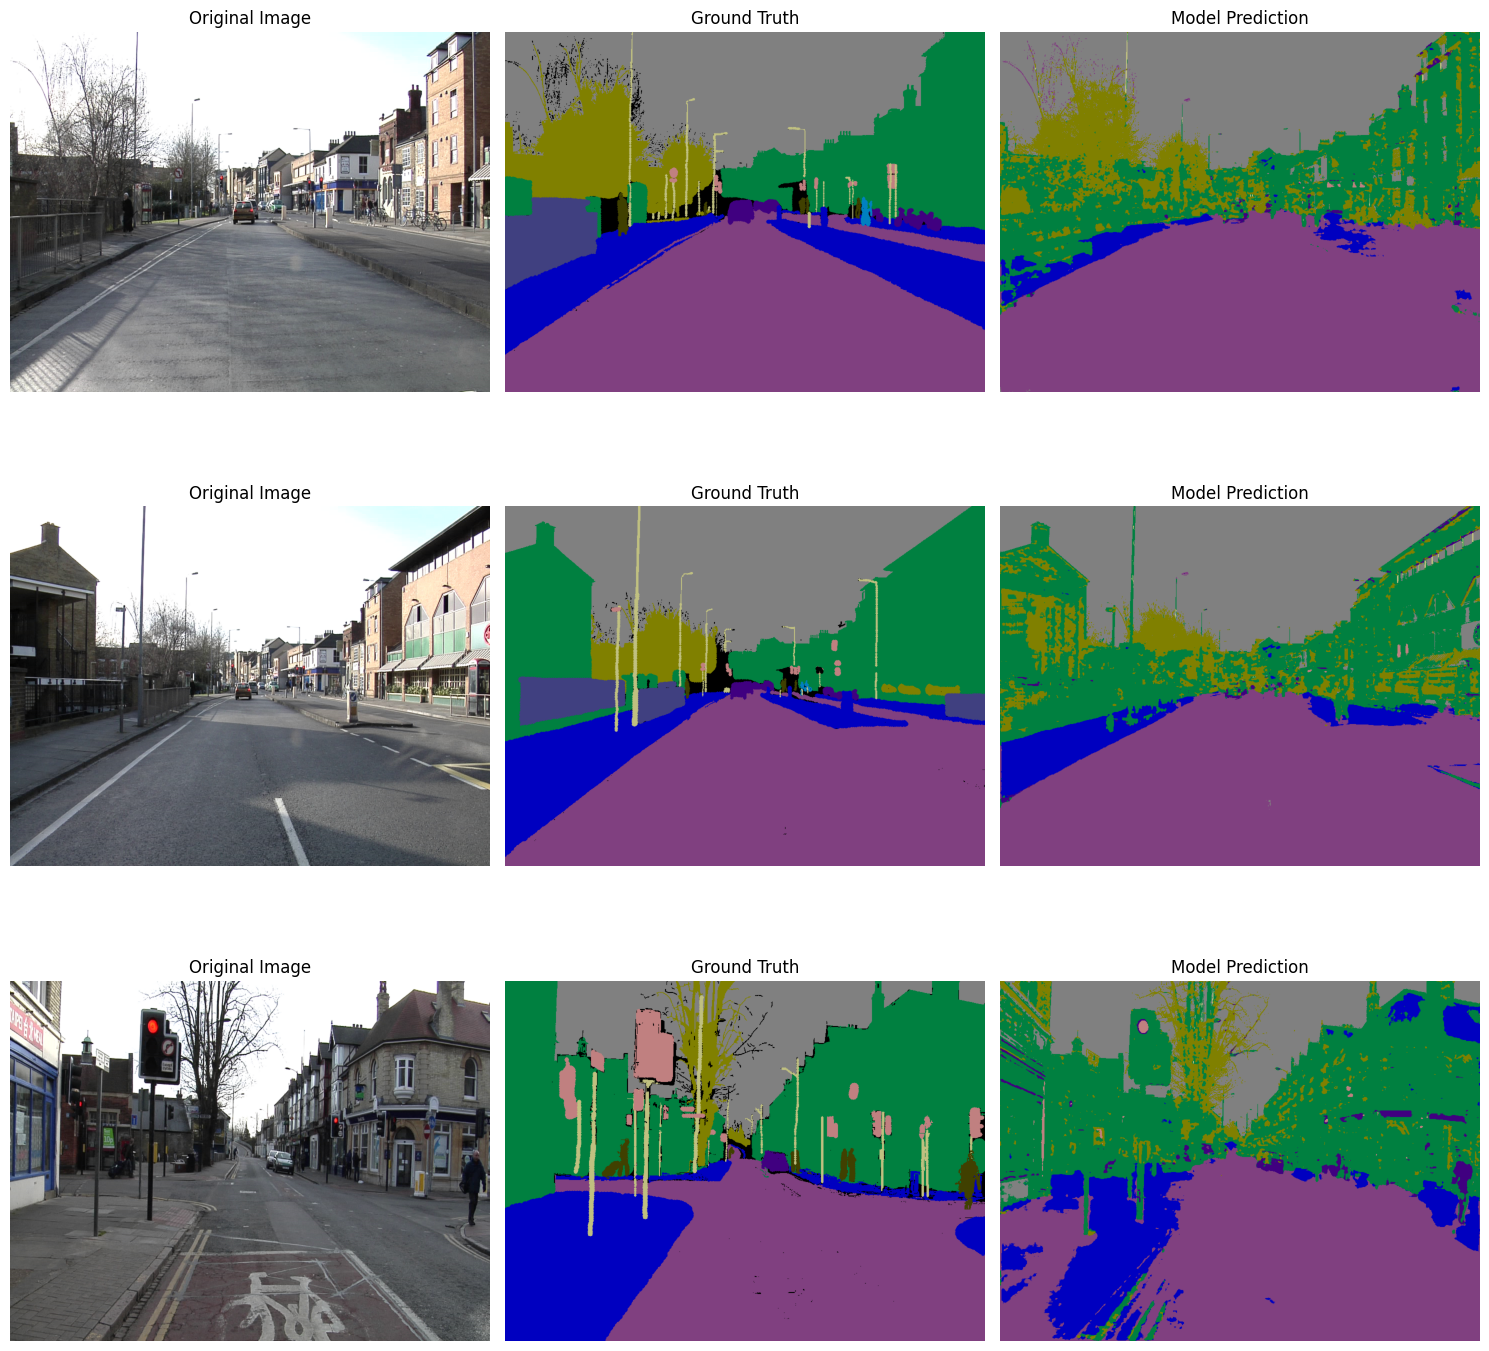

In [170]:
test_dataset = CamVidDataset(
    image_dir=test_images,
    mask_dir=test_masks,
    crop_size=(224, 224),
    is_train=False
)
# load best model weights
model.load_state_dict(torch.load('best_model.pth'))
visualize_predictions(model, test_dataset, num_samples=3)

**Answer the following Questions:**

<font color="red">**1. Do the errors your model makes seem semantic (wrong class) or spatial (wrong localization)?**
The errors are a mix of both. Spatial errors are very visible because the boundaries of objects like cars looks blurry instead of sharp lines. There are also Semantic errors, where the model confuses similar-looking categories, like labeling a Sidewalk as a Road.

</font>  

<font color="red">**2. Which component of the architecture most likely causes that type of error?**
Spatial errors caused by Transition Down layers. because max pooling discard fine pixel details to reduce images size, making it harder to recover sharp boundaries even with skip connections.
Semantic errors caused by a low Growth Rate, since a small value of growth rate limits the model, makes it hard for the model to tell the difference between different objects, like roads and sidewalks.

</font>  

<font color="red">**3. If you could change one design choice to address it, what would you alter?**
I would increase the Growth Rate (k) from 16 to 32. This gives the model more ability to learn extra features, which would help it create sharper object edges and more accurately tell the difference between classes.
</font>
